**Ciência de Dados**

Prof. Miguel Bozer da Silva - miguel.bozer@senaisp.edu.br

---

# Aula 04 — Visualização de Dados
**Objetivos da aula:**

- Entender o papel da visualização na análise de dados
- Criar gráficos básicos com matplotlib e seaborn
- Interpretar visualizações de forma crítica
- Aplicar boas práticas modernas de visualização

📌 Visualização não é apenas “fazer gráfico”.  
É uma ferramenta para **explorar, comunicar e tomar decisões com dados**.


## 1️⃣ Importando bibliotecas

As principais bibliotecas que utilizaremos serão:

- `pandas` → manipulação de dados
- `matplotlib` → base da visualização em Python
- `seaborn` → visualizações estatísticas modernas


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from googledrivedownloader import download_file_from_google_drive as gdd

## 2️⃣ Carregando o Dataset

Utilizaremos o dataset `tips`, disponível no seaborn.


In [3]:
# Baixar o arquivo do google drive:
data_google_id = "1FLGSndILtN9CZThO_trOds4hpZtlwc5i"
gdd(file_id=data_google_id, dest_path="./tips.csv", showsize=True, overwrite=True)

0.0 B Done.


In [4]:
df = pd.read_csv("./tips.csv")
df.head()

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


### Explorando rapidamente o dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [6]:
df.describe()

,Unnamed: 0,total_bill,tip,size
count,244.000000,244.000000,244.000000,244.000000
mean,121.500000,19.785943,2.998279,2.569672
std,70.580923,8.902412,1.383638,0.951100
min,0.000000,3.070000,1.000000,1.000000
25%,60.750000,13.347500,2.000000,2.000000
50%,121.500000,17.795000,2.900000,2.000000
75%,182.250000,24.127500,3.562500,3.000000
max,243.000000,50.810000,10.000000,6.000000


## 3️⃣ Distribuição de Variáveis Numéricas — Histograma

Mostra como os valores estão distribuídos.


### O que é um histograma?

Um histograma é um tipo de gráfico que mostra como os dados estão **distribuídos**.

Ele funciona dividindo os valores de uma variável numérica em intervalos (faixas) e contando quantos dados existem em cada intervalo.

Em outras palavras: Um histograma mostra quantas vezes os valores aparecem dentro de cada faixa de valores.

Exemplo simples

Se tivermos notas de alunos:

```python
5, 6, 7, 7, 8, 9, 10
```
O histograma pode agrupar assim:

```python
5–6 → 2 alunos
7–8 → 3 alunos
9–10 → 2 alunos
```

### Qual a sua finalidade?


- Entender a distribuição dos dados
- Identificar valores mais frequentes
- Detectar valores extremos (outliers)
- Analisar se os dados estão:
  - concentrados
  - espalhados
  - simétricos ou não

### Obtendo o Histograma MANUALMENTE

Vamos fazer isso devido aos conceitos que são aprendidos ao fazer o histograma manualmente. Entretato, para aplicações e projetos de aula use a próxima seção.

Definindo quantas categorias (barras) teremos

In [7]:
n_cols = 10

Calculando a largura dos intervalos de cada classe

Nossos dados vão de:

```python
min_val = 3.07
max_val = 50.81
```

In [8]:
min_val = df['total_bill'].min()
max_val = df['total_bill'].max()
print(f"min_val = {min_val}")
print(f"max_val = {max_val}")

min_val = 3.07
max_val = 50.81


Vamos calcular a largura de cada intervalo para definirmos a frequência de ocorrência em cada um deles:

```
largura = (50.81 - 3.07) / 10 = 4.774
```



In [10]:
largura = (max_val - min_val) / n_cols
print(f"largura = {largura}")

largura = 4.774


A largura permitira o cálculo dos intervalos do histograma:
```
3.07 + 0x4.774 = 3.07
3.07 + 1x4.774 = 7.84
3.07 + 2x4.774 = 12.62
3.07 + 3x4.774 = 17.39
3.07 + 4x4.774 = 22.17
3.07 + 5x4.774 = 26.94
3.07 + 6x4.774 = 31.71
3.07 + 7x4.774 = 36.49
3.07 + 8x4.774 = 41.26
3.07 + 9x4.774 = 46.04
3.07 + 10x4.774 = 50.81
```



3. Obtendo o intervalo dos valores:

In [14]:
barras = []
for i in range(n_cols + 1):
  limite = min_val + i * largura
  barras.append(limite)
print(barras)

[3.07, 7.843999999999999, 12.618, 17.392, 22.166, 26.94, 31.714, 36.488, 41.262, 46.036, 50.81]


Assim conseguimos obter os valores do intervalo do eixo X do histograma:

```
Intervalo 01: [3.07, 7.84)
Intervalo 02: [7.84, 12.618)
Intervalo 03: [12.618, 17.392)
Intervalo 04: [17.392, 22.166)
Intervalo 05: [22.166, 26.94)
Intervalo 06: [26.94, 31.714)
Intervalo 07: [31.714, 36.488)
Intervalo 08: [36.488, 41.262)
Intervalo 09: [41.262, 46.036)
Intervalo 10: [46.036, 50.81]
```
Vamos agora criar uma variável com esse formato:

In [21]:
intervalos = []
for i in range(len(barras)-1):
  intervalos.append([barras[i],barras[i+1]])
print(intervalos)

[[3.07, 7.843999999999999], [7.843999999999999, 12.618], [12.618, 17.392], [17.392, 22.166], [22.166, 26.94], [26.94, 31.714], [31.714, 36.488], [36.488, 41.262], [41.262, 46.036], [46.036, 50.81]]


In [26]:
minimo = intervalos[0][0]
maximo = intervalos[0][1]
((minimo <= df['total_bill']) & (df['total_bill'] < maximo)).sum()

np.int64(7)

In [40]:
frequencia = []
for inicio,fim in intervalos:
  quantidade = ((inicio <= df['total_bill']) & (df['total_bill'] < fim)).sum()
  frequencia.append(quantidade)
frequencia[-1] += (df['total_bill'].max()==df['total_bill']).sum()
print(frequencia)
sum(frequencia)

[np.int64(7), np.int64(42), np.int64(68), np.int64(51), np.int64(31), np.int64(19), np.int64(12), np.int64(7), np.int64(3), np.int64(4)]


np.int64(244)

In [41]:
(df['total_bill'].max()==df['total_bill']).sum()

np.int64(1)

Obtendo o histograma:


In [43]:
texto = []
for inicio,fim in intervalos:
  texto.append(str(f"{inicio:.2f} - {fim:.2f}"))
print(texto)

['3.07 - 7.84', '7.84 - 12.62', '12.62 - 17.39', '17.39 - 22.17', '22.17 - 26.94', '26.94 - 31.71', '31.71 - 36.49', '36.49 - 41.26', '41.26 - 46.04', '46.04 - 50.81']


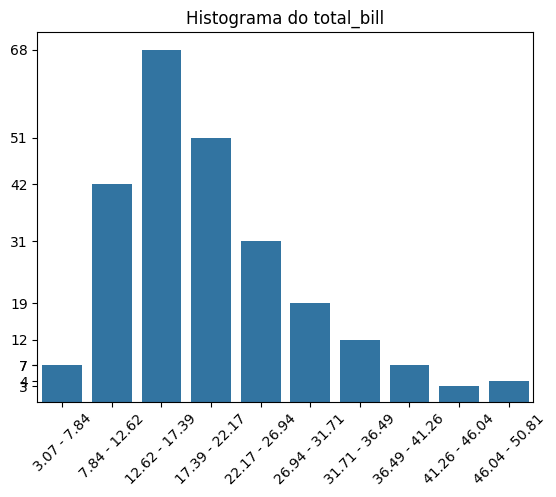

In [47]:
sns.barplot(x=texto, y=frequencia)
plt.title("Histograma do total_bill")
plt.xticks(rotation=45)
plt.yticks(frequencia)
plt.show()

### Obtendo o Histograma com as bibliotecas:

1. Vamos usar o `np.histogram` para obter os valores da frequência de ocorrência e os intervalos do nosso histograma. Esses valores vão nos ajudar a obter os

In [60]:
n_cols = 10
h = np.histogram(df["total_bill"], bins=n_cols)
print(h)
# Usamos o 'h' para estilizar o gráfico

(array([ 7, 42, 68, 51, 31, 19, 12,  7,  3,  4]), array([ 3.07 ,  7.844, 12.618, 17.392, 22.166, 26.94 , 31.714, 36.488,
       41.262, 46.036, 50.81 ]))


`n_cols = 10`

- Define o número de intervalos (bins)

Estrutura de h:

- `h[0]` → frequências;
- `h[1]` → limites dos intervalos

2. Vamos usar o `sns.histplot()` para gerar o histograma dos nossos dados:

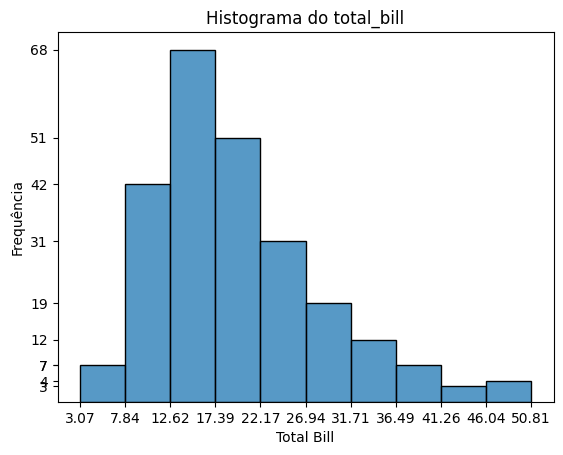

In [62]:
sns.histplot(df["total_bill"], bins=n_cols)
plt.yticks(h[0])
plt.xticks(h[1])
plt.title("Histograma do total_bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequência")
plt.show()

#### Explicando o `sns.histplot()`

Criando a figura:

`plt.figure(figsize=(8,8))`

- Define o tamanho do gráfico:
  - largura = 8
  - altura = 8

Criando o histograma:

`sns.histplot(df["total_bill"], bins=n_cols)`

- Aqui o seaborn:

- Pega os dados da coluna `total_bill`
- Divide em `n_cols` intervalos
- Conta quantos valores caem em cada intervalo
- Desenha as barras

Ajustando o eixo X e Y:

`plt.yticks(h[0])`

`plt.xticks(h[1])`

Usa os limites calculados com:

`np.histogram()`

## 4️⃣ Gráficos de Dispersão




### O que é um gráfico de dispersão?

Mostra relação entre duas variáveis numéricas.

Para cada linha da tabela:

- valor de uma coluna → eixo X
- valor de outra coluna → eixo Y

Podemos avaliar se **existe um padrão?**

- crescente
- decrescente
- nenhum padrão

Podemos avaliar **onde temos mais pontos**?

- região central
- extremos

Podemos detectar outliers (pontos isolados):

Eles podem indicar:
- erro
- comportamento diferente

### Criando gráficos de dispersão em python

Vamos criar um gráfico de dispersão para comparar as colunas `total_bill` e `tip`:

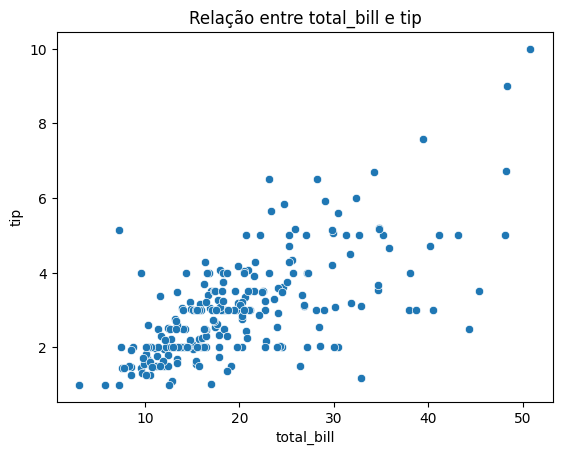

In [66]:
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Relação entre total_bill e tip")
plt.show()

- `sns.scatterplot(...)`: Função do seaborn usada para criar um gráfico de dispersão
  - `data=df`: Define de onde vem os dados
    - `df` é o nosso DataFrame;
    - Todas as colunas estão dentro dele;
  - `x="total_bill"`: Define os valores do eixo x
  - `y="tip"`: Define os valores do eixo y

Vamos adicionar a segregação entre os pontos que temos de acordo com a coluna `sex`

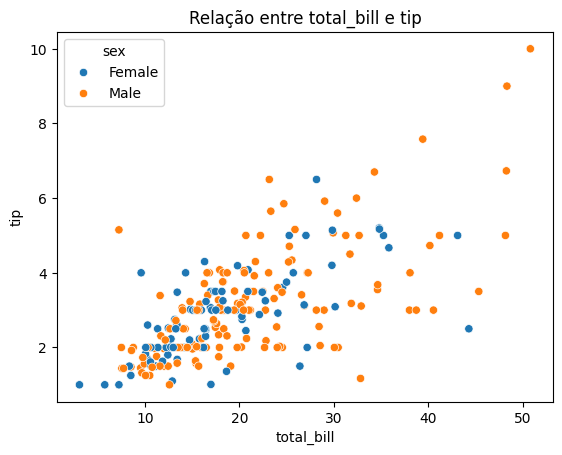

In [67]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue='sex')
plt.title("Relação entre total_bill e tip")
plt.show()

`hue` → adiciona cores por categoria

# 5️⃣ Gráficos de Barras


Podemos analisar os atributos **categóricos** usando gráficos de barras para comparar a frequência de ocorrência de cada categoria. Podemos usar o `sns.countplot()` para fazer esses gráficos:

Vamos fazer um gráfico considerando a coluna `day`

In [68]:
df['day'].unique()

array(['Sun', 'Sat', 'Thur', 'Fri'], dtype=object)

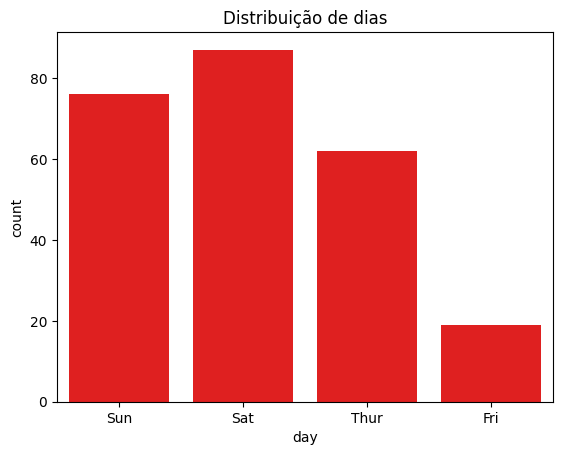

In [75]:
sns.countplot(data=df, x='day', color='red')
plt.title("Distribuição de dias")
plt.show()

- `sns.countplot(...)`: contar automaticamente os valores de uma coluna **categórica** e desenha um gráfico de barras;
  - `data=df`: Define de onde vem os dados
    - `df` é o nosso DataFrame;
    - Todas as colunas estão dentro dele;
  - `x='day'`: Define a variável que será analisada
    - `day` → coluna categórica (Sun, Sat, Thur, Fri)
    - Cada valor vira uma barra

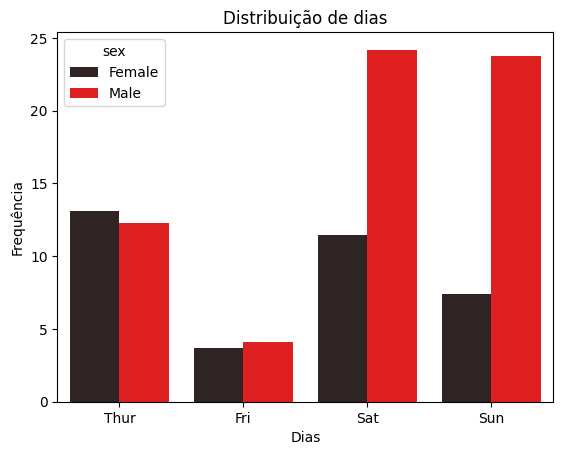

In [88]:
sns.countplot(data=df, x='day', palette='dark:red', hue='sex', stat='percent', order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Distribuição de dias")
plt.xlabel("Dias")
plt.ylabel("Frequência")
plt.show()

`hue` → divide os dados em sub-categorias e usa cores para diferenciá-las.

**O que isso permite analisar?**

- Comparações dentro de cada grupo:

  - Em qual dia homens dão mais gorjetas?
  - Mulheres aparecem mais em quais dias?
  - Existe diferença entre grupos?

Uma outra opção, não tão utilizada na área, são os gráficos de pizza:

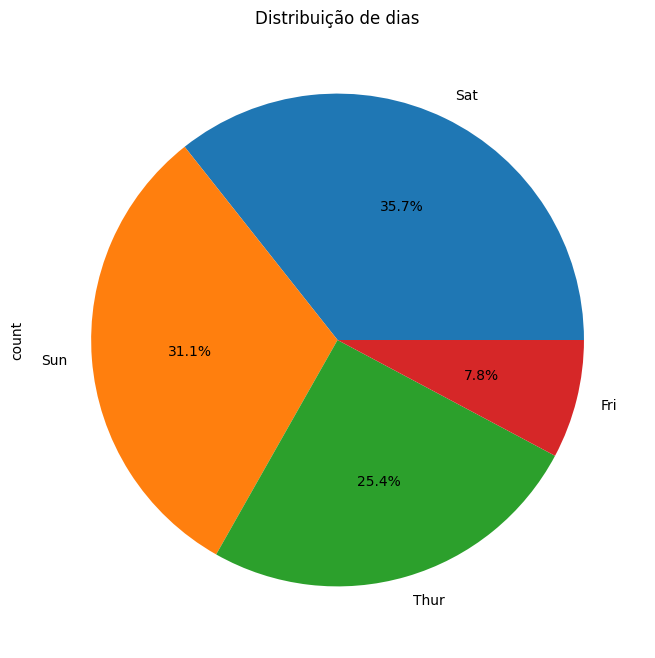

In [91]:
df['day'].value_counts().plot.pie(figsize=(8,8), autopct='%1.1f%%')
plt.title("Distribuição de dias")
plt.show()